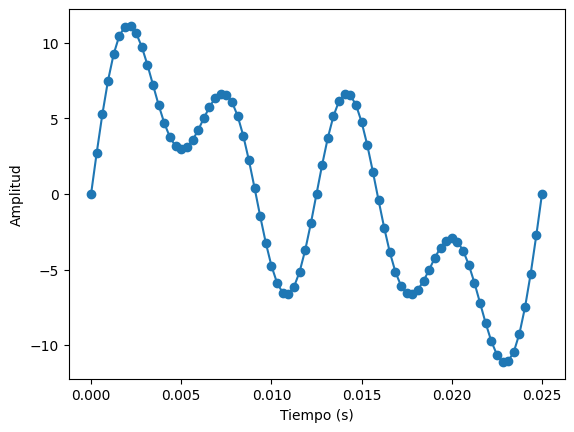

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

Fo = 40 # Frecuencia fundamental de la señal1
Fo1 = 80 # Frecuencia fundamental de la señal2
Fo2 = 160 # Frecuencia fundamental de la señal3
Tp= 1/40 # Periodo de la señal
Fs = 20*Fo2 # Frecuencia de muestreo-->investigar
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más
A = 5
A1 = 5
A2 = 5
x = A*np.sin(2*np.pi*Fo*t)
x1 = A1*np.sin(2*np.pi*Fo1*t)
x2 = A2*np.sin(2*np.pi*Fo2*t)
xt=x+x1+x2
plt.plot(t, xt, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

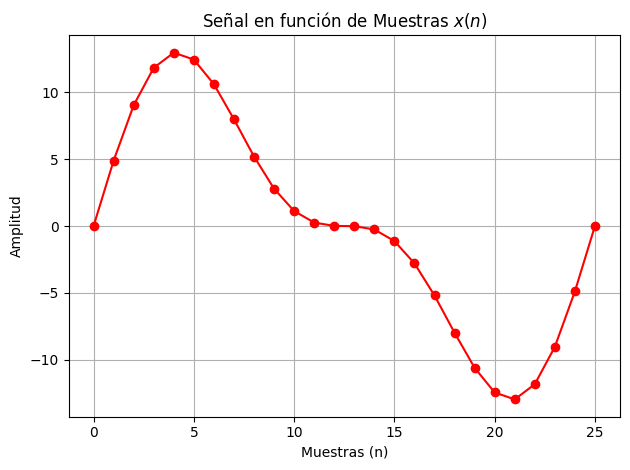

In [6]:
# 1. Frecuencias digitales normalizadas (fo = Fo / Fs)
fo1 = Fo / Fs
fo2 = Fo1 / Fs
fo3 = Fo2 / Fs

# 2. Vector de muestras (n) desde 0 hasta el largo del vector de tiempo anterior
n = np.arange(0, len(t))

# 3. Generación de la señal usando n y las frecuencias normalizadas
x_n1 = A * np.sin(2 * np.pi * fo1 * n)
x_n2 = A1 * np.sin(2 * np.pi * fo2 * n)
x_n3 = A2 * np.sin(2 * np.pi * fo3 * n)
xn = x_n1 + x_n2 + x_n3

# Gráfica en muestras

plt.plot(n, xn, marker='o', color='r')
plt.title('Señal en función de Muestras $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
print("\nPrimeras 5 muestras usando índices x(n):")
print(xn[:5])


Primeras 5 muestras usando índices x(n):
[ 0.          4.89566724  9.03917637 11.8356047  12.96741452]


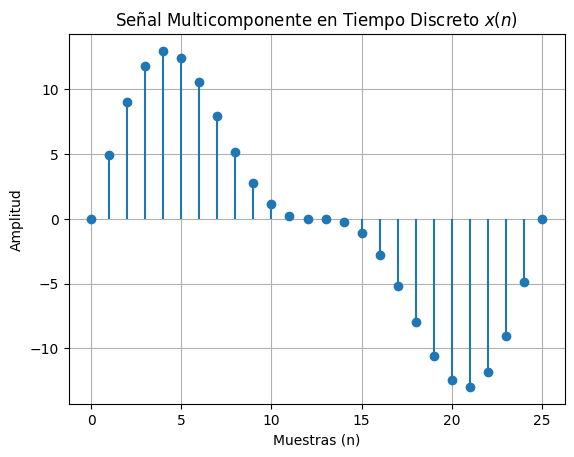

In [8]:
# Usamos stem en lugar de plot para ver los pulsos discretos
plt.stem(n, xn, basefmt=" ")

plt.title('Señal Multicomponente en Tiempo Discreto $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

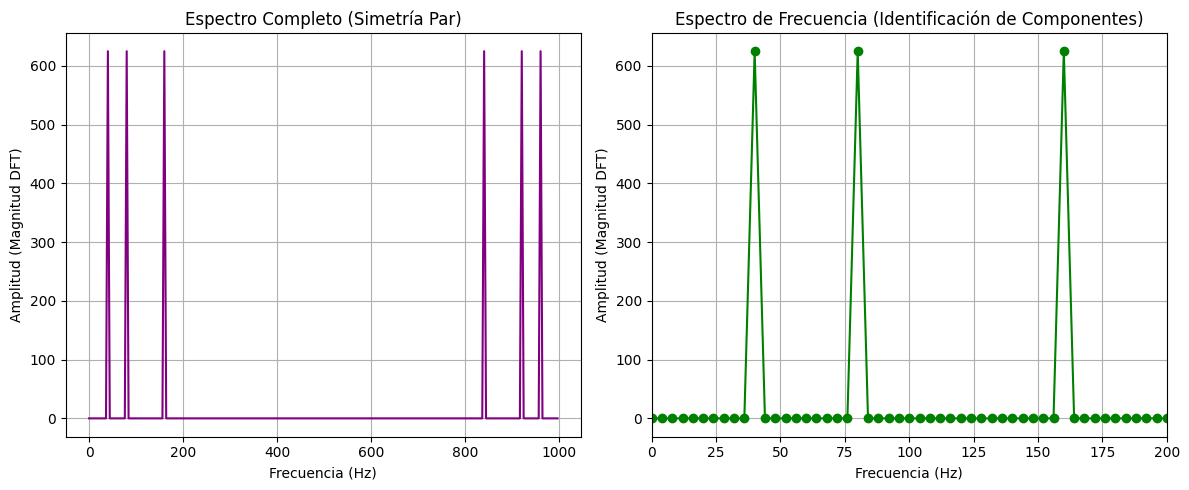

Número total de muestras (N): 250
Amplitud máxima teórica esperada en cada pico: N * (A / 2) = 250 * 2.5 = 625.0


In [11]:


# 1. PARÁMETROS DE LA SEÑAL (10 PERIODOS)

Fo1 = 40 
Fo2 = 80 
Fo3 = 160 

Fs = 1000  # Frecuencia de muestreo
T = 1/Fs   # Periodo de muestreo

# Un periodo de la frecuencia fundamental (la más baja)
Tp = 1/Fo1 

# Modificando el tiempo para capturar exactamente 10 periodos
# Duración total = 10 * Tp (0.25 segundos)
t_10 = np.arange(0, 10 * Tp, T) 

# Amplitudes de las tres componentes
A1, A2, A3 = 5, 5, 5

#  señal combinada para los 10 periodos
x10 = (A1 * np.sin(2 * np.pi * Fo1 * t_10) + 
       A2 * np.sin(2 * np.pi * Fo2 * t_10) + 
       A3 * np.sin(2 * np.pi * Fo3 * t_10))

# 2. CÁLCULO DE LA DFT (FFT)
X10 = np.fft.fft(x10)
N = len(X10) # Número total de muestras (debe dar 250)

# 3. GRAFICAR EL ESPECTRO COMPLETO ESCALADO EN FRECUENCIA (Hz)
F = np.arange(0, N) * Fs / N

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(F, abs(X10), color='purple')
plt.title('Espectro Completo (Simetría Par)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (Magnitud DFT)')
plt.grid(True)

# 4. GRAFICAR SOLO LA MITAD (HASTA NYQUIST) Y ACERCAR
Nmitad = int(np.ceil(N / 2))
Fmitad = F[0:Nmitad]
X10mitad = X10[0:Nmitad]

plt.subplot(1, 2, 2)
plt.plot(Fmitad, abs(X10mitad), marker='o', color='g')
plt.title('Espectro de Frecuencia (Identificación de Componentes)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (Magnitud DFT)')

# Ajuste el límite del eje X para ver  las 3 frecuencias (de 0 a 200 Hz)
plt.xlim(0, 200) 
plt.grid(True)

plt.tight_layout()
plt.show()

# 5. EXPLICACIÓN MATEMÁTICA DE LAS ALTURAS (Para tu informe)
print(f"Número total de muestras (N): {N}")
print(f"Amplitud máxima teórica esperada en cada pico: N * (A / 2) = {N} * 2.5 = {N * 2.5}")